In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import xarray as xr
import rioxarray as rxr
import rasterio
import dask.array as da

import geopandas as gpd
import geemap
import ee

import os
from glob import glob
import folium

import warnings
warnings.filterwarnings('ignore')

In [2]:
# List available cities in mnt/
cities = [d for d in os.listdir('mnt') if os.path.isdir(f'mnt/{d}') and d.startswith('20')]
print("Available cities:")
for i, city in enumerate(cities, 1):
    print(f"{i}. {city}")


Available cities:
1. 2025-10-senegal-tambacounda
2. 2025-10-senegal-diourbel
3. 2025-02-tunisia-tunis
4. 2025-10-indonesia-sofifi
5. 2025-10-senegal-dakar
6. 2025-10-senegal-matam


### Load Files

In [3]:
# Select city
city_dir = cities[4] # Change this to your city
cityname  = city_dir.split('-')[-1]  # Remove year prefix
data_dir = os.path.join('mnt', city_dir, '02-process-output', 'spatial')
temporal_dir = os.path.join('mnt', city_dir, '02-process-output', 'temporal')
aoi_dir = os.path.join('mnt', city_dir, '01-user-input', 'wards')


files = glob(data_dir  +   "/*")
t_files = glob(temporal_dir  +   "/*")
patterns = ['pop', 'osm', 'infrastructure', 'wsf', 'ndvi', 'rad', 'rwi', 'built', 'major_roads', 'gdp']
files = [f for f in files if any(p in f for p in patterns)]
aoi_file = glob(aoi_dir + "/*.shp")[0]
print(f"\nSelected: {city_dir}. data_dir: {data_dir}")
print(aoi_file)



Selected: 2025-10-senegal-dakar. data_dir: mnt/2025-10-senegal-dakar/02-process-output/spatial
mnt/2025-10-senegal-dakar/01-user-input/wards/senegal_dakar_wards.shp


In [4]:
tifs = [f for f in files if f.endswith('.tif')]
pop_tifs = [f for f in tifs if 'ghs_pop' in f]
built_tifs = [f for f in tifs if 'built' in f]
wsf_tifs = [f for f in tifs if 'wsf' in f]
rad_tifs = [f for f in tifs if 'rad' in f]
ndvi_tifs = [f for f in tifs if 'ndvi' in f ]
gdp_tifs = [f for f in files if 'gdp' in f ]

s1_tifs = [f for f in t_files if 's1_' in f]
s2_tifs = [f for f in t_files if 's2_' in f]
nl_tifs = [f for f in t_files if 'nightlight_' in f]

rwi_file = [f for f in files if "rwi" in f]
rwi_file

['mnt/2025-10-senegal-dakar/02-process-output/spatial/dakar_rwi.gpkg']

In [59]:
built

<xarray.DataArray (band: 1, y: 318, x: 440)> Size: 560kB
[139920 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 4kB -17.53 -17.53 -17.53 ... -17.11 -17.11 -17.11
  * y            (y) float64 3kB 14.89 14.89 14.89 14.89 ... 14.59 14.59 14.59
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [6]:
sorted(gdp_tifs)

['mnt/2025-10-senegal-dakar/02-process-output/spatial/dakar_grid_gdp.tif']

In [7]:
s2 = rxr.open_rasterio(sorted(s2_tifs)[-1], masked=True)
s1 = rxr.open_rasterio(sorted(s1_tifs)[-1], masked=True)
nl = rxr.open_rasterio(sorted(nl_tifs)[-1], masked=True)
pop = rxr.open_rasterio(sorted(pop_tifs)[-1], masked=True)
built = rxr.open_rasterio(sorted(built_tifs)[-1], masked=True)
gdp = rxr.open_rasterio(sorted(gdp_tifs)[-1], masked=True)
wsf = rxr.open_rasterio(sorted(wsf_tifs)[-1], masked=True)

#### AOI

In [8]:
aoi = gpd.read_file(aoi_file).to_crs("EPSG:4326")
rwi = gpd.read_file(rwi_file[0]).to_crs("EPSG:4326")

#### OSM DATA

In [9]:
osm_files = [f for f in files if "osm" in f]

osm = {}
for file in osm_files:
    name = file.split('/')[-1].replace('.gpkg', '')  # Get filename
    name = name.split('_osm_')[-1]  # Keep only the part after 'osm_'
    osm[name] = gpd.read_file(file).to_crs('EPSG:4326')
    print(f"Loaded {name}: {len(osm[name])} features")

Loaded retail: 30 features
Loaded industrial: 105 features
Loaded warehouses: 61 features
Loaded transport_hubs: 70 features
Loaded schools: 797 features
Loaded police: 47 features
Loaded residential: 7248 features
Loaded government: 47 features
Loaded education: 688 features
Loaded parking: 244 features
Loaded fire: 9 features
Loaded religious: 930 features
Loaded health: 140 features
Loaded roads: 248089 features
Loaded office_buildings: 22 features
Loaded swm: 63 features
Loaded commercial: 38 features
Loaded tourism: 151 features


In [10]:
import osmnx as ox

residential_types = {
    'landuse': 'residential',
    'building': 'residential',
    'building': 'apartments',
    'building': 'house',
    'place': 'neighbourhood'
}

all_residential = []

aoi_geom = aoi.geometry.unary_union

for key, value in residential_types.items():
    try:
        gdf = ox.features_from_polygon(aoi_geom, tags={key: value})
        gdf['osm_type'] = f"{key}_{value}"
        all_residential.append(gdf)
        print(f"Found {len(gdf)} features for {key}={value}")
    except Exception as e:
        print(f"No data for {key}={value}")

# Combine all
if all_residential:
    residential_combined = pd.concat(all_residential, ignore_index=True)
    
    # Convert to points
    residential_combined['geometry'] = residential_combined.geometry.centroid
    
    # Remove duplicates by location
    residential_combined = residential_combined.drop_duplicates(
        subset=['geometry'], keep='first'
    )
    
    residential_combined.to_file('residential_all.gpkg', driver='GPKG')
    print(f"Total: {len(residential_combined)} residential points")

residential_combined = residential_combined.to_crs('EPSG:4326') 

# residential_combined.to_file(data_dir +  '/' + cityname +'_osm_residential.gpkg', driver='GPKG')


Found 224 features for landuse=residential
Found 6948 features for building=house
Found 78 features for place=neighbourhood
Total: 7248 residential points


/var/folders/3l/jxlbywk944n4gwvl6pj216j00000gn/T/ipykernel_48924/154706183.py:29: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  residential_combined['geometry'] = residential_combined.geometry.centroid


In [11]:
osm['residential'] = residential_combined

In [12]:
osm.keys()

dict_keys(['retail', 'industrial', 'warehouses', 'transport_hubs', 'schools', 'police', 'residential', 'government', 'education', 'parking', 'fire', 'religious', 'health', 'roads', 'office_buildings', 'swm', 'commercial', 'tourism'])

In [13]:
s = ['residential', 'retail', 'commercial', 'industrial',  'warehouses', 'tourism', 'office_buildings']


# Map each item to a color
color_map = {'residential': "lightblue",
             'retail':  "purple",
             'commercial': "red",
             'office_buildings': "brown",
             'industrial': "orange",
             'warehouses': "khaki",
             'tourism': "green",
             'government': "maroon",
             
             }
color_map

{'residential': 'lightblue',
 'retail': 'purple',
 'commercial': 'red',
 'office_buildings': 'brown',
 'industrial': 'orange',
 'warehouses': 'khaki',
 'tourism': 'green',
 'government': 'maroon'}

In [14]:
osm['industrial']

,amenity,name,geometry
0,None,None,POINT (-17.39176 14.74243)
1,None,None,POINT (-17.40338 14.7379)
2,None,None,POINT (-17.43613 14.72125)
3,None,Sococim Industries,POINT (-17.24488 14.70601)
4,None,Parfumerie Gandour,POINT (-17.4215 14.73345)
...,...,...,...
100,None,Poste de patte d'Oie,POINT (-17.43253 14.73701)
101,None,None,POINT (-17.24336 14.71429)
102,None,None,POINT (-17.24463 14.71247)
103,None,Port autonome de Dakar,POINT (-17.42742 14.6834)


/Users/vivaldirinaldi/miniforge3/envs/cityscan/lib/python3.10/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


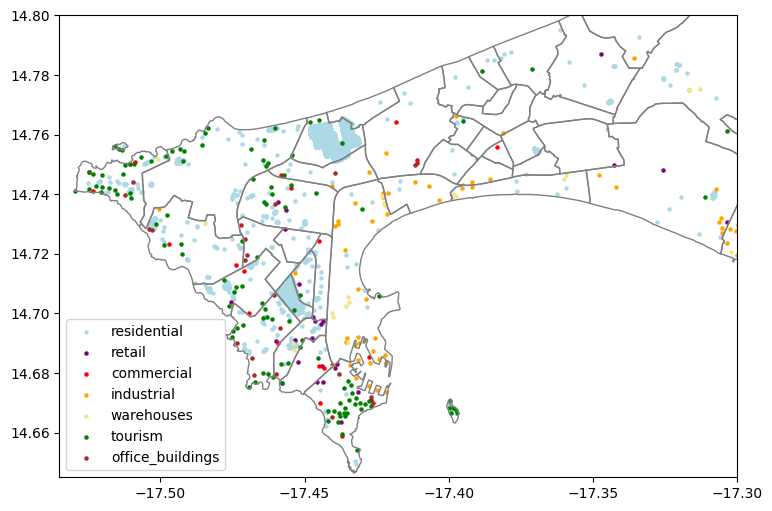

In [15]:
plt.figure(figsize=(10, 6))

# Use xarray plotting - handles coordinates automatically
# s2[:3][::-1].plot.imshow(rgb='band', vmin=0, vmax=3000, alpha=0.6)

# Now AOI will overlay correctly
aoi.boundary.plot(ax=plt.gca(), color='grey', linewidth=1)

# rwi.plot(column='rwi', cmap='OrRd', legend=True, alpha=0.3, ax=plt.gca())

for  n, i in enumerate(s):
    osm[i].plot(ax=plt.gca(), color=color_map[i], markersize=5, alpha=1, label=i)

plt.legend()

# xmin, xmax = -17.535, -17.415
# ymin, ymax = 14.645, 14.77


xmin, xmax = -17.535, -17.3
ymin, ymax = 14.645, 14.8


plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax )
plt.show()


### Create new ROI and clip

In [16]:
from shapely.geometry import box


# Create bbox polygon
roi_geom = box(xmin, ymin, xmax, ymax)
roi = gpd.GeoDataFrame([1], geometry=[roi_geom], crs='EPSG:4326')

aoi_clipped = aoi.clip(roi)

# Filter POIs within bbox
filtered_osm = {}
for name in s:
    clipped = osm[name].clip(roi)
    if len(clipped) > 0:
        filtered_osm[name] = clipped


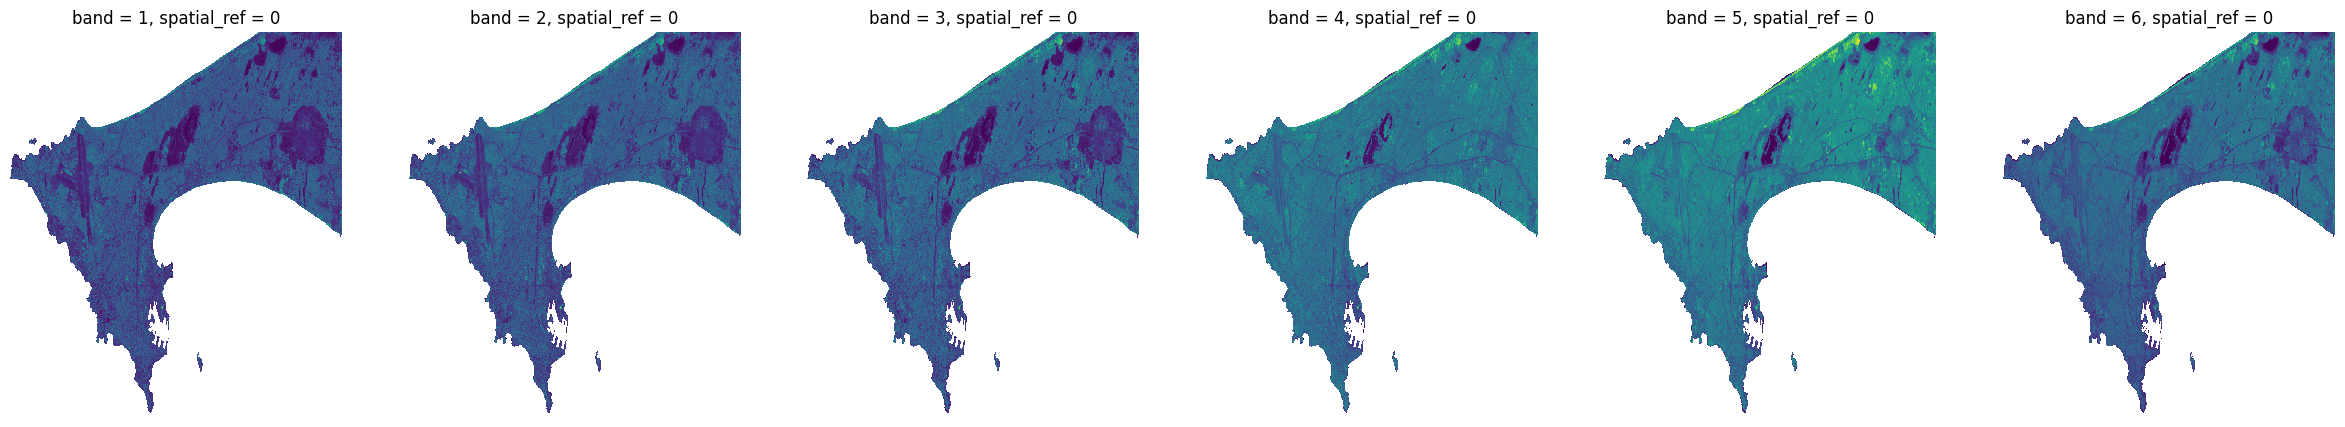

In [17]:
# Clip raster
s2c = s2.rio.clip([roi_geom], roi.crs)

plt.figure(figsize=(30, 5))
for i in range(s2c.shape[0]):
    plt.subplot(1, s2c.shape[0], i+1)
    s2c[i].plot(add_colorbar=False)
    plt.axis('off')


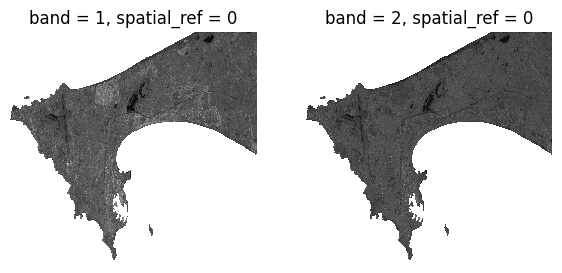

In [18]:
s1c = s1.rio.clip([roi_geom], roi.crs)

plt.figure(figsize=(7, 3))
for i in range(s1c.shape[0]):
    plt.subplot(1, s1c.shape[0], i+1)
    s1c[i].plot(add_colorbar=False, cmap='gray')
    plt.axis('off')


(-17.541331338394844,
 -17.288508031505007,
 14.638751921518297,
 14.8076784799277)

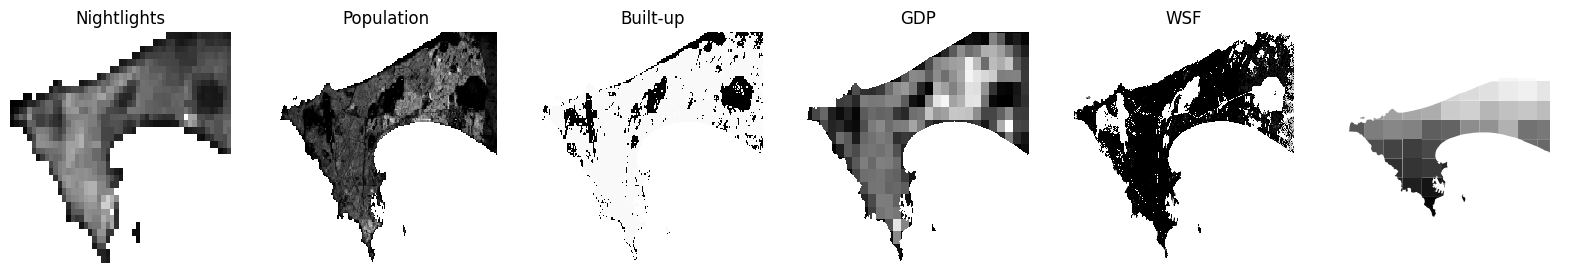

In [19]:
nlc = nl.rio.clip([roi_geom], roi.crs)
popc = pop.rio.clip([roi_geom], roi.crs)
builtc = built.rio.clip([roi_geom], roi.crs)
gdpc = gdp.rio.clip([roi_geom], roi.crs)
wsfc = wsf.rio.clip([roi_geom], roi.crs)

rwic = rwi.clip(roi_geom)
plt.figure(figsize=(20, 3))

for i, c in enumerate([nlc, popc, builtc, gdpc  , wsfc]):
    plt.subplot(1, 6, i+1)
    c[-1].plot(add_colorbar=False, cmap='gray')
    plt.title(['Nightlights', 'Population', 'Built-up', 'GDP', "WSF"][i])
    plt.axis('off')

plt.subplot(1, 6, i+2)
rwic.plot( cmap='gray', ax=plt.gca())
plt.axis('off')

#### Reclassing OSM

In [20]:
osm_classes = {
    'residential': filtered_osm.get('residential', gpd.GeoDataFrame()).sample(frac=0.1),
    
    'commercial': pd.concat([
        filtered_osm.get('retail', gpd.GeoDataFrame()),
        filtered_osm.get('commercial', gpd.GeoDataFrame()),
        filtered_osm.get('office_buildings', gpd.GeoDataFrame()),
        filtered_osm.get('tourism', gpd.GeoDataFrame())
    ]) if any(k in filtered_osm for k in ['retail', 'commercial', 'office_buildings', 'tourism']) else gpd.GeoDataFrame(),
    
    'industrial': pd.concat([
        filtered_osm.get('industrial', gpd.GeoDataFrame()),
        filtered_osm.get('warehouses', gpd.GeoDataFrame())
    ]) if any(k in filtered_osm for k in ['industrial', 'warehouses']) else gpd.GeoDataFrame()
}

# Remove empty dataframes
osm_classes = {k: v for k, v in osm_classes.items() if len(v) > 0}

classes = list(osm_classes.keys())

for k, v in osm_classes.items():
    print(f"  {k}: {len(v)} points")

  residential: 701 points
  commercial: 191 points
  industrial: 79 points


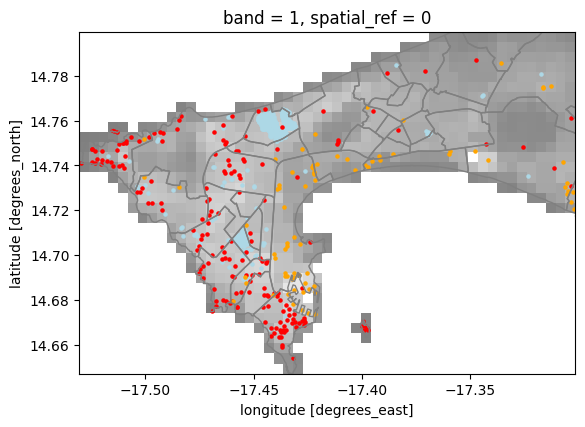

In [21]:
# Now AOI will overlay correctly
aoi_clipped.boundary.plot(ax=plt.gca(), color='grey', linewidth=1)

nlc[-1].plot(add_colorbar=False, cmap='gray', alpha=0.5)
for  n, i in enumerate(classes):
    osm_classes[i].plot(ax=plt.gca(), color=color_map[i], markersize=5, alpha=1, label=i)


# plt.legend()

#### Specificy raster target resolution

In [22]:
from rasterio.enums import Resampling

# Create land mask from population
land_mask = (popc > 0).astype('float32')  

# Resample to desired resolution
target_resolution = (0.0025, -0.0025)  # ~200m

target = land_mask.rio.reproject(
    'EPSG:4326',
    resolution=target_resolution,
    resampling=Resampling.nearest  # Use nearest for binary mask
)

print(f"Target shape: {target.shape}")
print(f"Resolution: {target.rio.resolution()}")

# Now use this as target for everything

Target shape: (1, 62, 95)
Resolution: (0.0025, -0.0025)


#### Create IDW parameters

In [54]:
# Parameters
k_neighbors = 10
power = 2
max_distance = 0.1  # ~1km in degrees


In [55]:
from sklearn.neighbors import NearestNeighbors

# Get raster grid
height, width = target.shape[1:]  # Use built layer as reference
transform = target.rio.transform()

# Create pixel coordinates
rows, cols = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')
xs, ys = rasterio.transform.xy(transform, rows.flatten(), cols.flatten())
pixel_coords = np.column_stack([xs, ys])

print(f"Creating soft labels for {len(pixel_coords)} pixels...")

# Initialize soft label arrays
classes = ['residential', 'commercial', 'industrial']
soft_labels = np.zeros((height, width, 3), dtype='float32')  # 3 classes
class_indices = {c: i for i, c in enumerate(classes)}

# For each class, calculate influence
for class_name, gdf in osm_classes.items():
    if class_name not in class_indices:
        continue
    
    class_idx = class_indices[class_name]
    print(f"Processing {class_name}...")
    
    # Get coordinates
    osm_coords = np.column_stack([gdf.geometry.x, gdf.geometry.y])
    
    # Build nearest neighbors
    n_neighbors = min(k_neighbors, len(osm_coords))
    nbrs = NearestNeighbors(n_neighbors=n_neighbors, algorithm='ball_tree')
    nbrs.fit(osm_coords)
    
    # Process in batches
    batch_size = 10000
    for i in range(0, len(pixel_coords), batch_size):
        batch = pixel_coords[i:i+batch_size]
        distances, _ = nbrs.kneighbors(batch)
        
        # IDW weights
        epsilon = 1e-10
        weights = 1 / (distances + epsilon)**power
        weights[distances > max_distance] = 0
        
        # Sum influence
        influence = weights.sum(axis=1)
        soft_labels[:, :, class_idx].flat[i:i+len(batch)] = influence

Creating soft labels for 5890 pixels...
Processing residential...
Processing commercial...
Processing industrial...


/Users/vivaldirinaldi/miniforge3/envs/cityscan/lib/python3.10/site-packages/sklearn/utils/parallel.py:135: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vivaldirinaldi/miniforge3/envs/cityscan/lib/python3.10/site-packages/sklearn/utils/parallel.py:135: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vivaldirinaldi/miniforge3/envs/cityscan/lib/python3.10/site-packages/sklearn/utils/parallel.py:135: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


In [56]:
water_mask = (target > 0)  # Areas with buildings
# Or use a proper water mask if you have one

# Apply mask to soft labels
for i in range(3):
    soft_labels[:, :, i] = soft_labels[:, :, i] * water_mask

# Re-normalize after masking
total = soft_labels.sum(axis=2, keepdims=True)
total[total == 0] = 1
soft_labels = soft_labels / total

In [57]:
def create_extent(  raster):
    """Create geographic extent from rasterio xarray."""
    return [ float(raster.x.min()), float(raster.x.max()),float(raster.y.min()), float(raster.y.max())]

Plotting extent:    0                                           geometry
0  1  POLYGON ((-17.3 14.645, -17.3 14.8, -17.535 14...


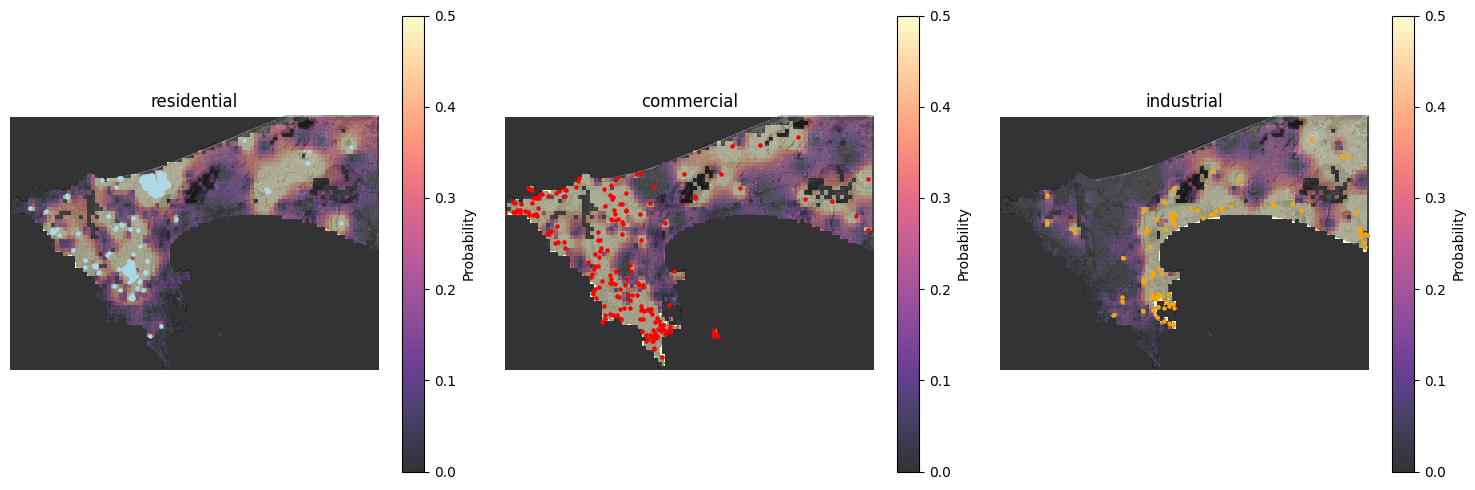

In [58]:
plt.figure(figsize=(15, 5))

extent = create_extent(target)
print(f"Plotting extent: {roi}")

for i, c in enumerate(classes):
    plt.subplot(1, 3, i+1)
    
    # Plot S2 background
    s2c[-1].plot(add_colorbar=False, cmap='gray', alpha=0.5)
    
    # Plot soft labels WITH EXTENT - THIS IS KEY
    plt.imshow(soft_labels[:, :, i], 
               cmap='magma', 
               extent=extent,  # Geographic coordinates
               origin='upper',  # Match S2 orientation
               vmin=0, 
               vmax=0.5,
               alpha=0.8)
    
    # Overlay OSM points
    osm_classes[c].plot(ax=plt.gca(), 
                       color=color_map[c], 
                       markersize=5, 
                       alpha=1)
    
    plt.title(c)
    plt.colorbar(label='Probability')
    plt.axis('off')

plt.tight_layout()
plt.show()

#### Set Raster inputs

In [28]:
import spyndex

idx = spyndex.computeIndex(
    index = ["NDBI","NDVI", "SAVI"],
    params = {
        "B": s2c.sel(band =1),
        "G": s2c.sel(band =2),
        "R": s2c.sel(band =3),
        "N": s2c.sel(band =4),
        "S1":s2c.sel(band =5),
        "L": 0.5
    }
)

# for i in ["NDBI","NDVI", "SAVI"]:
#     idx.sel(index = i).rio.write_crs("EPSG:4326")

s2indices = {}

for i in ["NDBI","NDVI", "SAVI"]:
    s2idx = s2c.sel(band=1).copy()
    s2idx.values = idx.sel(index = i).values
    s2indices[i] = s2idx



saridx = spyndex.computeIndex(
    index = ["VDDPI","NDPolI", "DPDD", "VHVVR"],
    params = {
        "VV": s2c.sel(band =1),
        "VH": s2c.sel(band =2),
    }
)

sarindices = {} 
for i in ["VDDPI","NDPolI", "DPDD", "VHVVR"]:
    saridx_raster = s1c.sel(band=1).copy()
    saridx_raster.values = saridx.sel(index = i).values
    sarindices[i] = saridx_raster





Processing s1_vv...
Processing s1_vh...
Processing s2_b2...
Processing s2_b3...
Processing s2_b4...
Processing s2_b8...
Processing ndbi...
Processing ndvi...
Processing savi...
Processing vddpi...
Processing ndpoli...
Processing dpdd...
Processing vvhr...
Processing nightlight...
Processing population...
s1_vv: (62, 95)
s1_vh: (62, 95)
s2_b2: (62, 95)
s2_b3: (62, 95)
s2_b4: (62, 95)
s2_b8: (62, 95)
ndbi: (62, 95)
ndvi: (62, 95)
savi: (62, 95)
vddpi: (62, 95)
ndpoli: (62, 95)
dpdd: (62, 95)
vvhr: (62, 95)
nightlight: (62, 95)
population: (62, 95)


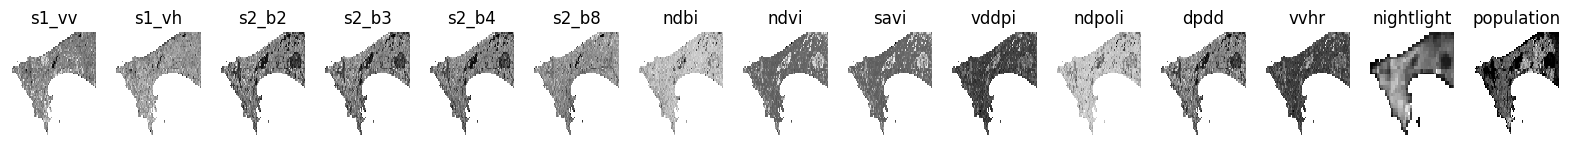

In [29]:
# Put all rasters in a dict
rasters = {
    's1_vv': s1c.sel(band=1),
    's1_vh': s1c.sel(band=2),
    's2_b2': s2c.sel(band=1),
    's2_b3': s2c.sel(band=2),
    's2_b4': s2c.sel(band=3),
    's2_b8': s2c.sel(band=4),
    'ndbi': s2indices['NDBI'],
    'ndvi': s2indices['NDVI'],
    'savi': s2indices['SAVI'],
    'vddpi': sarindices['VDDPI'],
    'ndpoli': sarindices['NDPolI'],
    'dpdd': sarindices['DPDD'],   
    "vvhr": sarindices["VHVVR"],
    'nightlight': nlc.sel(band=1),
    # 'built': builtc.squeeze(),
    'population': popc.squeeze(),
}

for name, raster in rasters.items():
    print(f"Processing {name}...")
    aligned = raster.rio.reproject_match(target)
    # Normalize to 0-1
    rasters[name] = (aligned - aligned.min()) / (aligned.max() - aligned.min())

for k in rasters.keys():
    print(f"{k}: {rasters[k].shape}")

plt.figure(figsize=(20, 3))
for i, (n, r) in enumerate(rasters.items()):
    plt.subplot(2, len(rasters), i+1)
    r.plot(cmap = "Greys_r", add_colorbar=False)
    plt.title(n)
    plt.axis('off')

In [30]:
confidence_threshold = 0.1


# High confidence: One class dominates (max > 0.7)
max_prob = soft_labels.max(axis=2)

# Overlapping: At least 2 classes > 0.
n_confident_classes = (soft_labels > confidence_threshold).sum(axis=2)
overlap_zones = n_confident_classes >= 2
 
overlap_pixels = np.where(overlap_zones.flatten())[0]

print(f"Total overlapping pixels: {len(overlap_pixels)}")

Total overlapping pixels: 901


In [31]:
n_high_total = int(overlap_zones.sum() / 0.7 * 0.3)
n_per_class = n_high_total // 3  # Split equally among 3 classes

high_confidence = max_prob > 0.5

# 4. Get candidate high-confidence pixels per class
high_conf_pixels = {
    'residential': np.where((high_confidence & (soft_labels[:,:,0] > 0.7)).flatten())[0],
    'commercial': np.where((high_confidence & (soft_labels[:,:,1] > 0.7)).flatten())[0],
    'industrial': np.where((high_confidence & (soft_labels[:,:,2] > 0.7)).flatten())[0],
}

# 5. Sample balanced high-confidence pixels
np.random.seed(42)
selected_high = []
for class_name, pixels in high_conf_pixels.items():
    if len(pixels) > 0:
        selected = np.random.choice(pixels, 
                                   min(n_per_class, len(pixels)), 
                                   replace=False)
        selected_high.extend(selected)
        print(f"  {class_name}: {len(selected)} pixels")

  residential: 128 pixels
  commercial: 128 pixels
  industrial: 128 pixels


In [32]:
training_indices = np.concatenate([overlap_pixels, selected_high])

In [33]:
mask_height, mask_width = soft_labels.shape[:2]

# Convert 1D indices to 2D
train_y = training_indices // mask_width
train_x = training_indices % mask_width

# Convert to geographic coordinates  
xs_train = extent[0] + (train_x + 0.5) / mask_width * (extent[1] - extent[0])
ys_train = extent[3] - (train_y + 0.5) / mask_height * (extent[3] - extent[2])

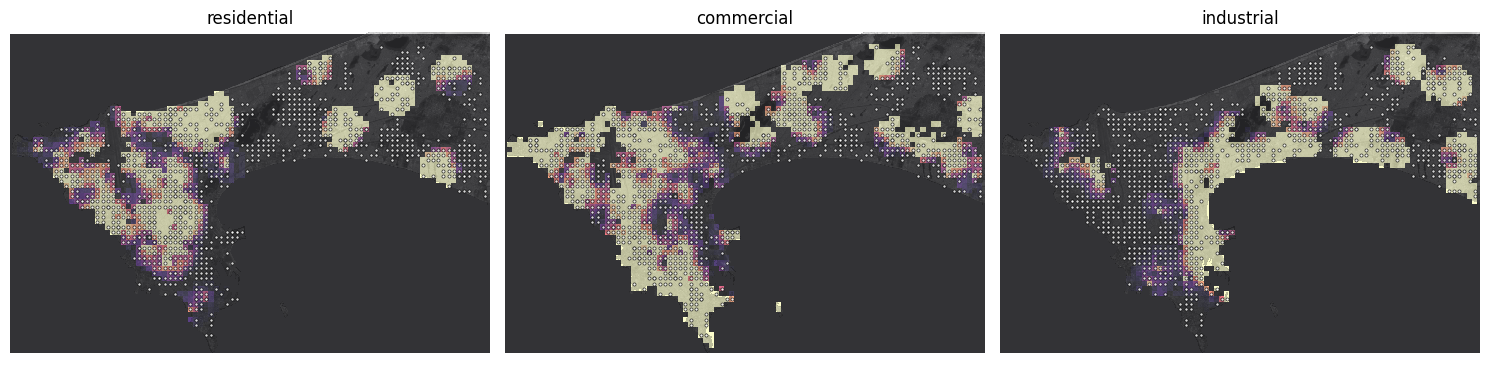

In [34]:
plt.figure(figsize=(15, 5))


for i, c in enumerate(classes):
    plt.subplot(1, 3, i+1)
    
    # Plot S2 background
    s2c[-1].plot(add_colorbar=False, cmap='gray', alpha=0.3)
    
    # Plot soft labels WITH EXTENT - THIS IS KEY
    plt.imshow(soft_labels[:, :, i], cmap='magma', extent=extent, origin='upper',  vmin=0, vmax=0.5, alpha=0.8)
    
    plt.scatter(xs_train, ys_train, c='white', s=5, alpha=0.8, 
                edgecolors='black', linewidths=0.5)
    
    plt.title(c)

    plt.axis('off')

plt.tight_layout()
plt.show()

In [35]:
X = np.stack([rasters[k].values for k in rasters.keys()], axis=-1)
X_flat = X.reshape(-1, X.shape[-1])

# Get soft labels
y_flat = soft_labels.reshape(-1, 3)

# Extract training samples
X_train = X_flat[training_indices]
y_train = y_flat[training_indices].argmax(axis=1)

print(f"Training on {len(X_train)} samples")
print(f"Features: {X_train.shape}")

Training on 1285 samples
Features: (1285, 15)


#### Dimension Reduction

In [36]:
print(f"NaN in X_train: {np.isnan(X_train).sum()}")

# Fill NaN with feature mean
X_train_filled = np.nan_to_num(X_train, nan=np.nanmean(X_train, axis=0))

NaN in X_train: 102


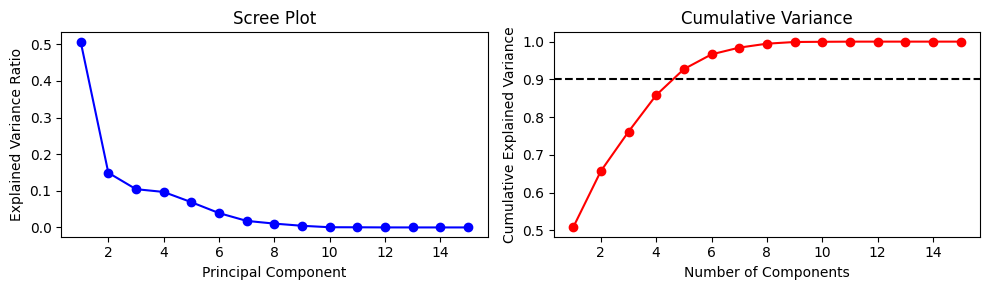

Components for 95% variance: 5


In [37]:
# Apply PCA
from sklearn.decomposition import PCA

pca_full = PCA()
pca_full.fit(X_train_filled)

# Plot explained variance
plt.figure(figsize=(10, 3))

# Scree plot
plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1), 
         pca_full.explained_variance_ratio_, 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')


# Cumulative variance
plt.subplot(1, 2, 2)
cumsum = pca_full.explained_variance_ratio_.cumsum()
plt.plot(range(1, len(cumsum) + 1), cumsum, 'ro-')
plt.axhline(y=0.90, color='k', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Variance')



plt.tight_layout()
plt.show()

n_components = (cumsum >= 0.90).argmax() + 1
print(f"Components for 95% variance: {n_components}")

In [38]:
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_filled)

print(f"Original features: {X_train.shape[1]}")
print(f"PCA components: {n_components}")
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.3f}")

Original features: 15
PCA components: 5
Explained variance: 0.927


In [39]:
# Transform ALL pixels with same PCA
X_flat_filled = np.nan_to_num(X_flat, nan=np.nanmean(X_train, axis=0))
X_flat_pca = pca.transform(X_flat_filled)  

#### Train Test Split

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

In [41]:
# Split into train/test
Xtr, Xts, ytr, yts = train_test_split(
    X_train_pca, y_train, 
    test_size=0.2, 
    random_state=42,
    stratify=y_train  # Ensure balanced classes
)

print(f"Training: {len(Xtr)}, Testing: {len(Xts)}")


Training: 1028, Testing: 257


#### Traning Model 

In [42]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb

In [43]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, max_depth=10, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=10, random_state=42),
    'Naive Bayes': GaussianNB(),
    'Neural Net': MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42),
}

In [44]:
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    model.fit(Xtr, ytr)
    
    # Evaluate on test set
    y_pred_test = model.predict(Xts)
    acc = accuracy_score(yts, y_pred_test)
    print(f"  Test accuracy: {acc:.3f}")
    
    # Predict on all pixels
    X_flat_pca = pca.transform(X_flat_filled)
    y_pred_proba = model.predict_proba(X_flat_pca)
    y_pred_map = y_pred_proba.reshape(soft_labels.shape[0], soft_labels.shape[1], 3)
    
    results[name] = {
        'model': model,
        'predictions': y_pred_map,
        'test_accuracy': acc
    }

Training Logistic Regression...
  Test accuracy: 0.389
Training Random Forest...


/Users/vivaldirinaldi/miniforge3/envs/cityscan/lib/python3.10/site-packages/sklearn/utils/parallel.py:135: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vivaldirinaldi/miniforge3/envs/cityscan/lib/python3.10/site-packages/sklearn/utils/parallel.py:135: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vivaldirinaldi/miniforge3/envs/cityscan/lib/python3.10/site-packages/sklearn/utils/parallel.py:135: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/

  Test accuracy: 0.467
Training Extra Trees...
  Test accuracy: 0.475
Training XGBoost...


/Users/vivaldirinaldi/miniforge3/envs/cityscan/lib/python3.10/site-packages/sklearn/utils/parallel.py:135: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vivaldirinaldi/miniforge3/envs/cityscan/lib/python3.10/site-packages/sklearn/utils/parallel.py:135: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/vivaldirinaldi/miniforge3/envs/cityscan/lib/python3.10/site-packages/sklearn/utils/parallel.py:135: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/

  Test accuracy: 0.490
Training Gradient Boosting...
  Test accuracy: 0.455
Training Naive Bayes...
  Test accuracy: 0.377
Training Neural Net...
  Test accuracy: 0.486


/Users/vivaldirinaldi/miniforge3/envs/cityscan/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


#### Test Model 

In [45]:
for name, res in results.items():
    print(f"{name}: {res['test_accuracy']:.3f}")

Logistic Regression: 0.389
Random Forest: 0.467
Extra Trees: 0.475
XGBoost: 0.490
Gradient Boosting: 0.455
Naive Bayes: 0.377
Neural Net: 0.486


In [46]:
results.keys()

dict_keys(['Logistic Regression', 'Random Forest', 'Extra Trees', 'XGBoost', 'Gradient Boosting', 'Naive Bayes', 'Neural Net'])

#### Plot results

 - Logistic Regression...


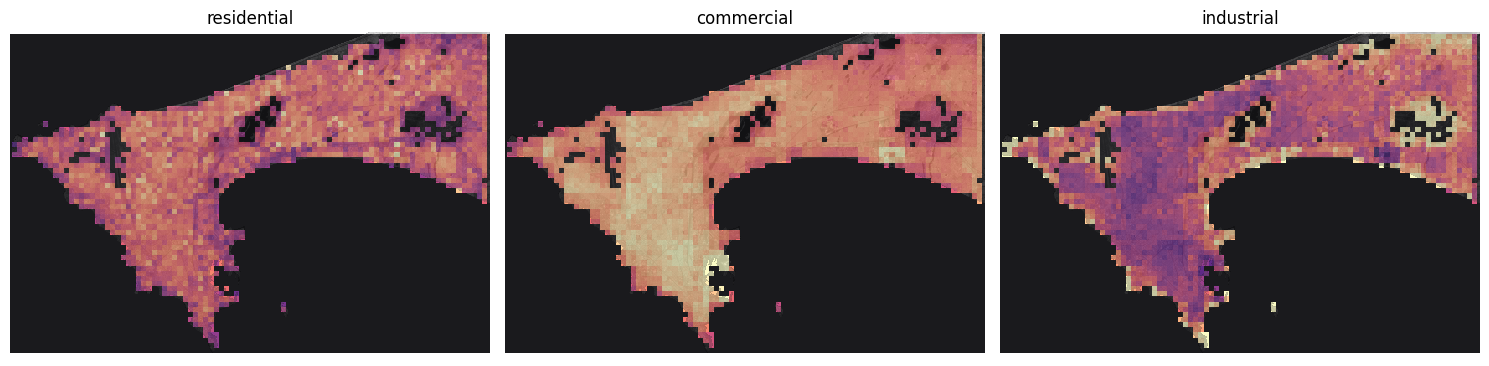

 - Random Forest...


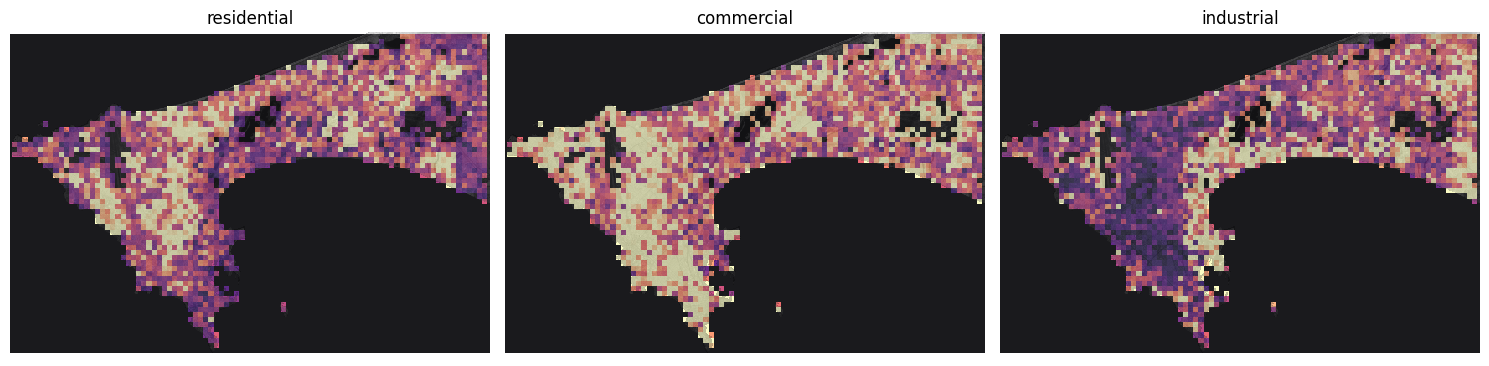

 - Extra Trees...


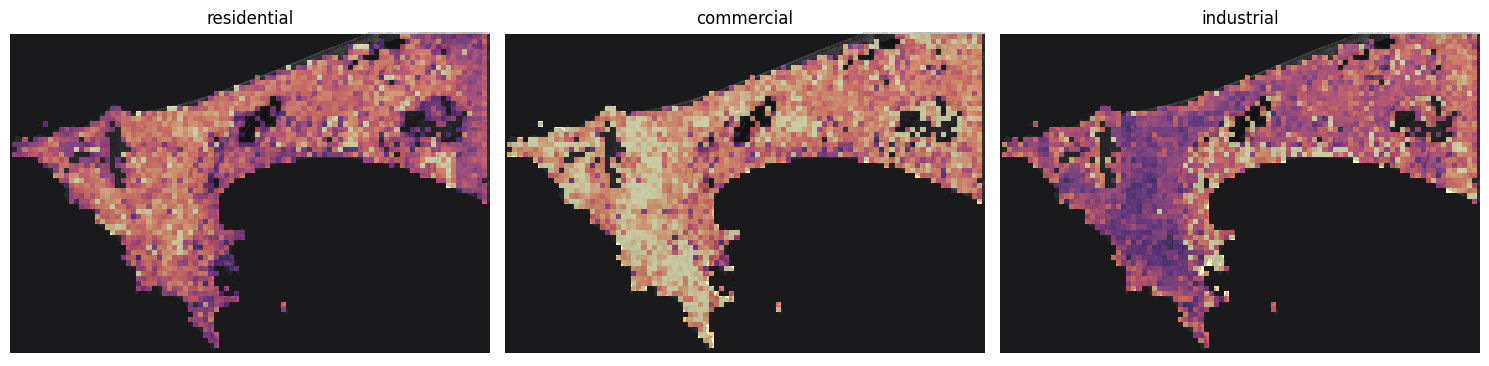

 - XGBoost...


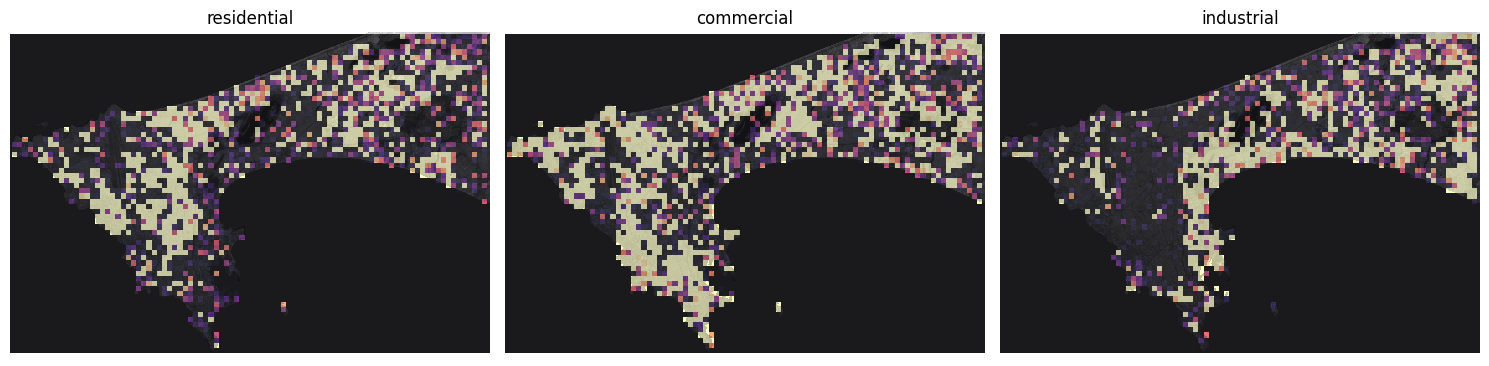

 - Gradient Boosting...


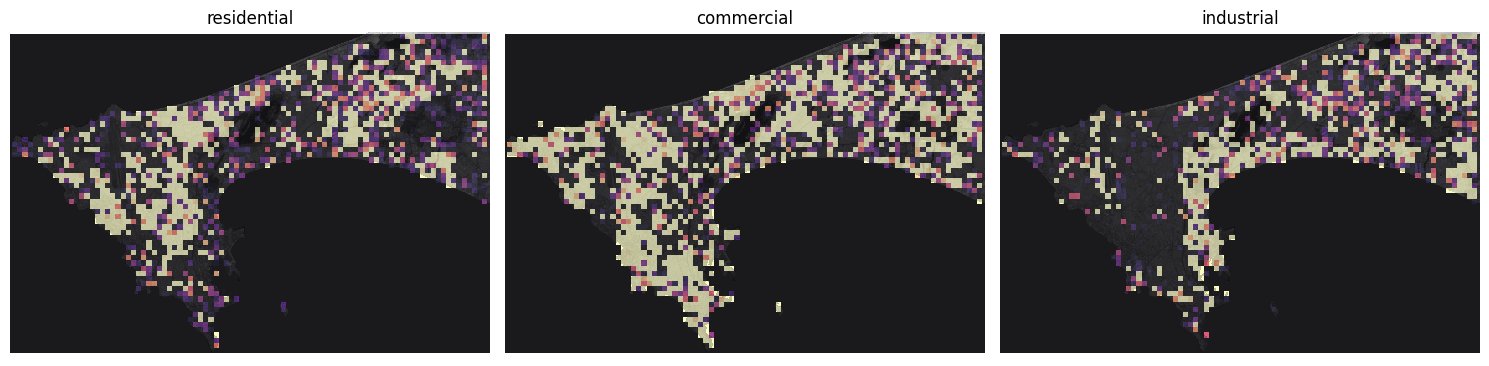

 - Naive Bayes...


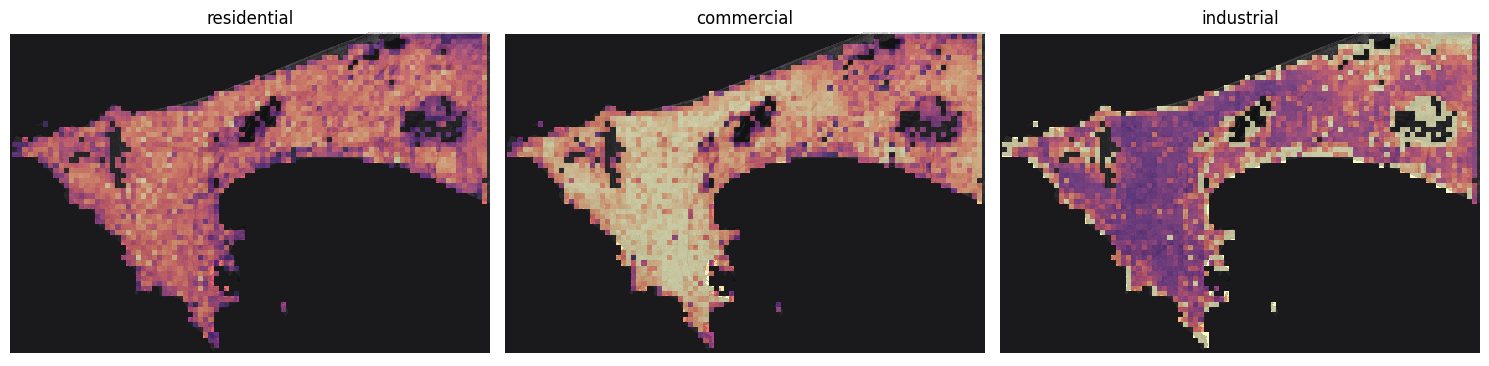

 - Neural Net...


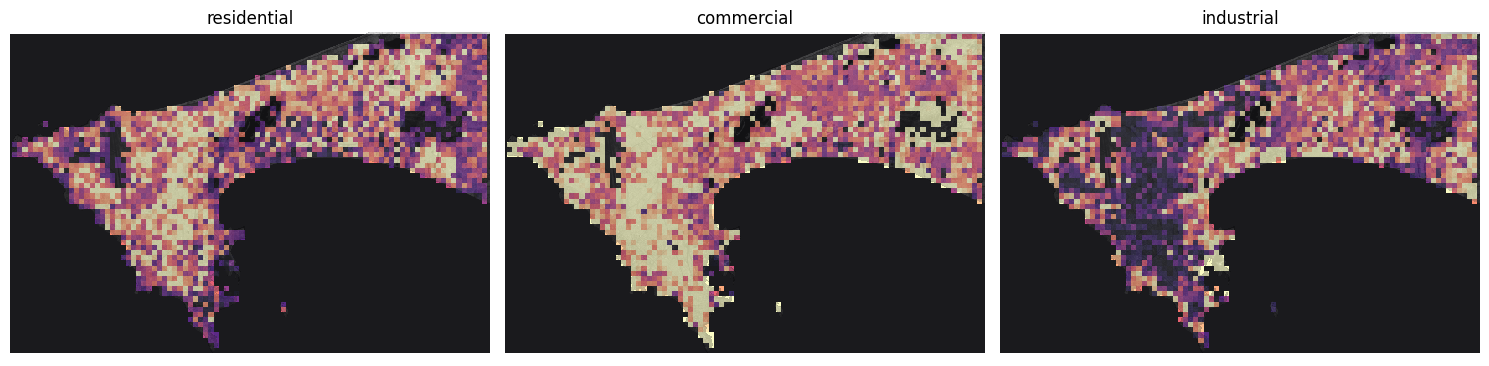

In [47]:
for model in results.keys():
    print(f" - {model}...")

    y_pred_map = results[model]['predictions']

    # Apply mask to soft labels
    for i in range(3):
        y_pred_map[:, :, i] = y_pred_map[:, :, i] * water_mask
        
    plt.figure(figsize=(15, 5))
    for i, c in enumerate(classes):
        plt.subplot(1, 3, i+1)
        
        # Plot S2 background
        s2c[-1].plot(add_colorbar=False, cmap='gray', alpha=0.3)
        
        # Plot soft labels WITH EXTENT - THIS IS KEY
        plt.imshow(y_pred_map[:, :, i], cmap='magma', extent=extent, origin='upper',  vmin=0, vmax=0.5, alpha=0.9)
        

        plt.title(c)

        plt.axis('off')

    plt.tight_layout()
    plt.show()

### Compare to RWI / GDP

In [48]:
gdpc[-1].values.shape

(1726, 2559)

 - Logistic Regression...


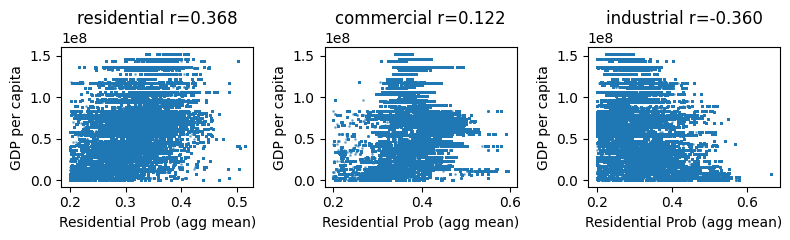

 - Random Forest...


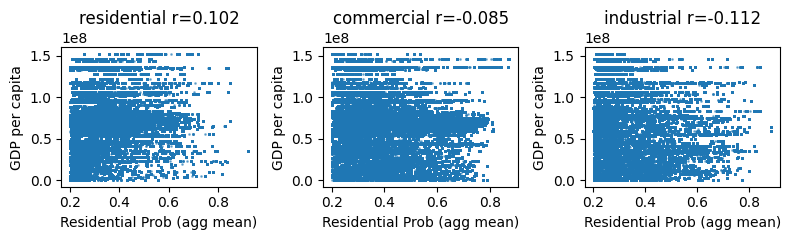

 - Extra Trees...


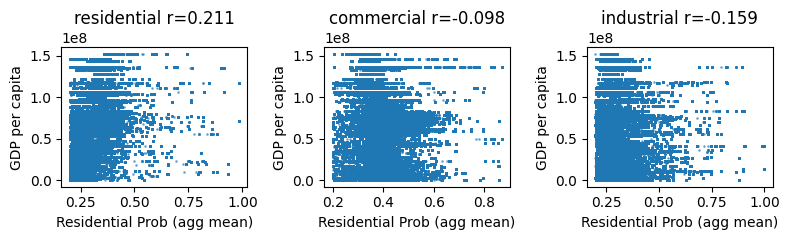

 - XGBoost...


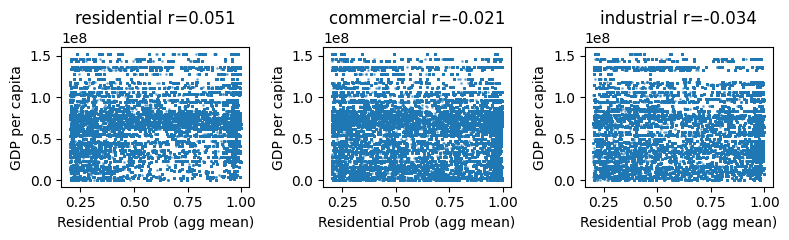

 - Gradient Boosting...


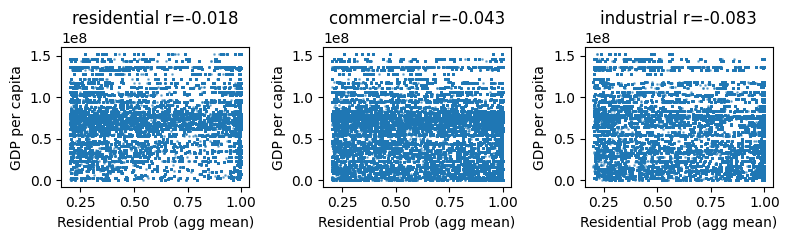

 - Naive Bayes...


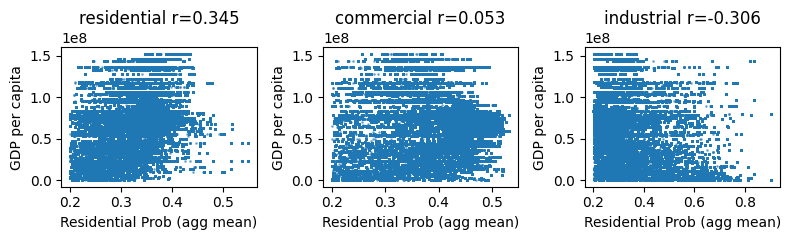

 - Neural Net...


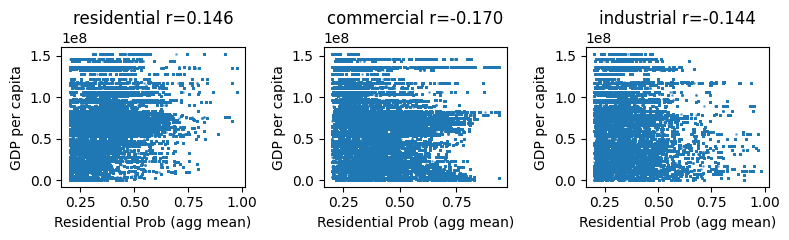

In [49]:
from rasterio.enums import Resampling
from scipy.stats import pearsonr

for model in models.keys():
    print(f" - {model}...")
    pred_map = results[model]['predictions']

    # Create xarray with band dimension
    pred_da = xr.DataArray(
        pred_map.transpose(2, 0, 1),  # (3, height, width) - bands first
        dims=['band', 'y', 'x'],
        coords={'band': classes, 'y': target.y, 'x': target.x}
    )

    pred_da.rio.write_crs(target.rio.crs, inplace=True)

    # Aggregate all bands at once
    pred_coarse = pred_da.rio.reproject_match(
        gdpc,
        resampling=Resampling.average
    )

    gdp_flat = gdpc[-1].values.flatten()

    plt.figure(figsize=(8, 2.5))
    for l in range(3):
        pred_flat = pred_coarse[l].values.flatten()
    
        valid = ~np.isnan(pred_flat) & ~np.isnan(gdp_flat) & (pred_flat > 0.2)
        corr, pval = pearsonr(pred_flat[valid], gdp_flat[valid])

        plt.subplot(1, 3, l+1)
        plt.scatter(pred_flat[valid], gdp_flat[valid], alpha=0.5, s=1)
        plt.xlabel('Residential Prob (agg mean)')
        plt.ylabel('GDP per capita')
        plt.title(f'{classes[l]} r={corr:.3f}')
    
    plt.tight_layout()
    plt.show()




 - Logistic Regression...
 - Random Forest...
 - Extra Trees...
 - XGBoost...
 - Gradient Boosting...
 - Naive Bayes...
 - Neural Net...


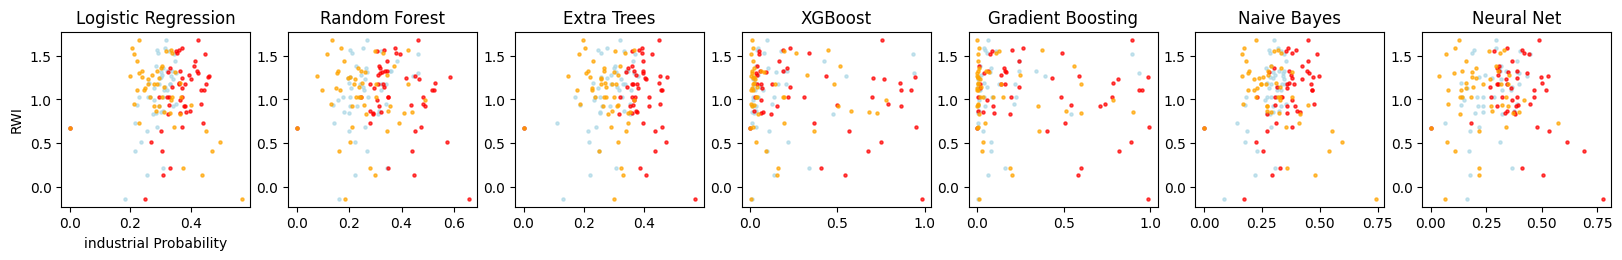

In [50]:
from rasterstats import zonal_stats

transform = target.rio.transform()
plt.figure(figsize=(20, 5))

for m, model in enumerate(models.keys()):
    print(f" - {model}...")
    pred_map = results[model]['predictions']

    for i, c in enumerate(classes):
        
        stats = zonal_stats(
            rwic,  # Your GeoDataFrame
            pred_map[:, :, i],
            affine=transform,
            stats=['median'],
            nodata=np.nan
        )
        rwic[c + '_prob'] = [s['median'] for s in stats]


    
    plt.subplot(2, len(models.keys()), m+1)
    for i, c in enumerate(classes):
        plt.scatter(rwic[c + '_prob'], rwic['rwi'], alpha=0.7, c=color_map[c], label=c,  s = 5)
    
        if m == 0:
            plt.xlabel(f'{c} Probability')
            plt.ylabel('RWI')
        plt.title(model)  
        
plt.show()
        


#### Time Series Plots

In [51]:
for i, y in enumerate(np.arange(2018, 2025)):

    s2ts = sorted(s2_tifs)[i]
    s1ts = sorted(s1_tifs)[i]
    nlts = sorted(nl_tifs)[i]


In [52]:
for i in range(len(s2_tifs)):
    print(sorted(s2_tifs)[i])

print()
for i in range(len(s1_tifs)):
    print(sorted(s1_tifs)[i])

# s2 = rxr.open_rasterio(sorted(s2_tifs)[-1], masked=True)
# s1 = rxr.open_rasterio(sorted(s1_tifs)[-1], masked=True)
# nl = rxr.open_rasterio(sorted(nl_tifs)[-1], masked=True)

mnt/2025-10-senegal-dakar/02-process-output/temporal/s2_2018.tif
mnt/2025-10-senegal-dakar/02-process-output/temporal/s2_2019.tif
mnt/2025-10-senegal-dakar/02-process-output/temporal/s2_2020.tif
mnt/2025-10-senegal-dakar/02-process-output/temporal/s2_2021.tif
mnt/2025-10-senegal-dakar/02-process-output/temporal/s2_2022.tif
mnt/2025-10-senegal-dakar/02-process-output/temporal/s2_2023.tif
mnt/2025-10-senegal-dakar/02-process-output/temporal/s2_2024.tif

mnt/2025-10-senegal-dakar/02-process-output/temporal/dakar_s1_2018.tif
mnt/2025-10-senegal-dakar/02-process-output/temporal/dakar_s1_2019.tif
mnt/2025-10-senegal-dakar/02-process-output/temporal/dakar_s1_2020.tif
mnt/2025-10-senegal-dakar/02-process-output/temporal/dakar_s1_2021.tif
mnt/2025-10-senegal-dakar/02-process-output/temporal/dakar_s1_2022.tif
mnt/2025-10-senegal-dakar/02-process-output/temporal/dakar_s1_2023.tif
mnt/2025-10-senegal-dakar/02-process-output/temporal/dakar_s1_2024.tif


### Folium interactive map

In [53]:
# # Add each gpkg layer
# colors = ['blue', 'red', 'green', 'orange', 'purple', 'pink', 
#           'brown', 'gray', 'cyan', 'magenta']


# m = folium.Map(location=[14.7, -17.4], zoom_start=12)

# for i, (name, gdf) in enumerate(gdfs.items()):
#     folium.GeoJson(
#         gdf,
#         name=name.replace('dakar_osm_', ''),
#         marker=folium.CircleMarker(
#             radius=3,  # Small dots
#             fill=True,
#             fillColor=colors[i % len(colors)],
#             color=colors[i % len(colors)],
#             fillOpacity=0.7
#         )
#     ).add_to(m)

# folium.LayerControl().add_to(m)
# m